In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load data
df = pd.read_csv("../data/processed/features_v2.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values("date")

# Train-test split (same as before)
split_date = df['date'].quantile(0.8)

train = df[df['date'] < split_date].copy()
test  = df[df['date'] >= split_date].copy()


In [3]:
target = "avgLapTime_s"

drop_cols = [
    "raceId", "driverId", "constructorId",
    "date",
    "positionOrder",
    "points",
    "avgLapTime_s"

]

features = [col for col in df.columns if col not in drop_cols]

X_train = train[features]
X_test  = test[features]

y_train = train[target]
y_test  = test[target]


In [4]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

lap_preds = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, lap_preds))
print("R2:", r2_score(y_test, lap_preds))

MAE: 12.22076755152696
R2: 0.1557671764022095


In [5]:
results_lap = test.copy()

results_lap["prediction"] = lap_preds
results_lap["error"] = results_lap["avgLapTime_s"] - results_lap["prediction"]
results_lap["abs_error"] = np.abs(results_lap["error"])


circuitId
76    29.985012
13    25.615414
39    21.843394
75    21.670670
1     19.963393
9     19.799489
22    19.634093
77    19.611069
3     17.336817
79    15.911391
Name: abs_error, dtype: float64


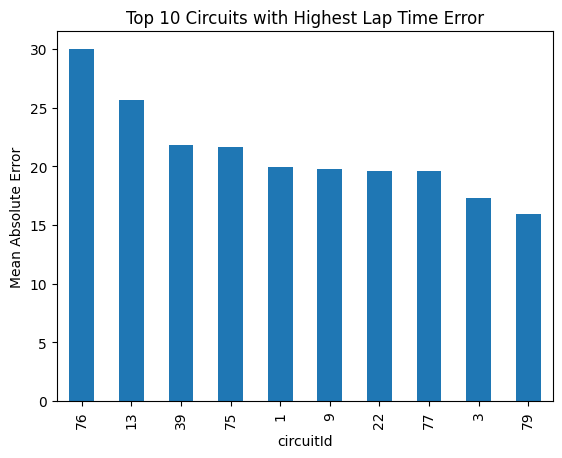

In [6]:
circuit_errors_lap = (
    results_lap
    .groupby("circuitId")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print(circuit_errors_lap.head(10))


circuit_errors_lap.head(10).plot(kind="bar")
plt.title("Top 10 Circuits with Highest Lap Time Error")
plt.ylabel("Mean Absolute Error")
plt.show()


circuitId
3     65.825401
11    56.540514
13    45.511529
22    29.946747
9     29.493051
1     29.294144
77    27.191265
73    18.487964
39    17.002323
6     15.197470
Name: avgLapTime_s, dtype: float64


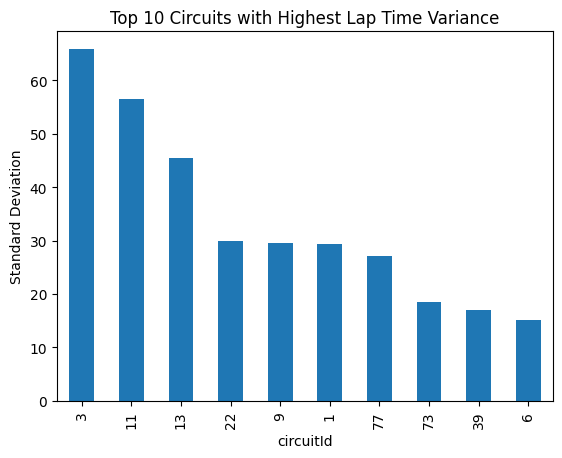

In [7]:
circuit_variance = (
    test
    .groupby("circuitId")["avgLapTime_s"]
    .std()
    .sort_values(ascending=False)
)

print(circuit_variance.head(10))

circuit_variance.head(10).plot(kind="bar")
plt.title("Top 10 Circuits with Highest Lap Time Variance")
plt.ylabel("Standard Deviation")
plt.show()


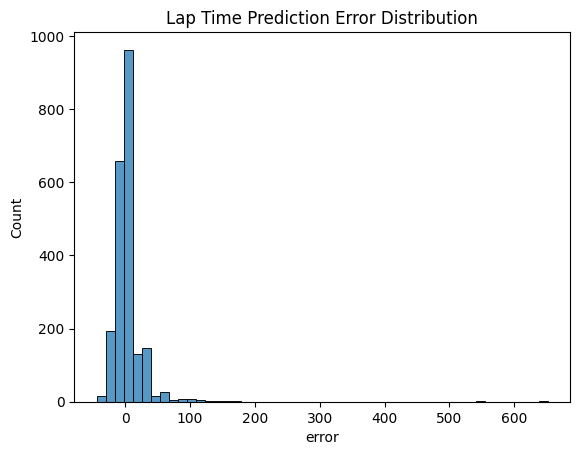

In [8]:
sns.histplot(results_lap["error"], bins=50)
plt.title("Lap Time Prediction Error Distribution")
plt.show()
